# This notebook is suggested to run on your local machine in a good network environment, or you may run into trouble when creating dataset

### download all the module we will need

In [2]:
!pip install overpy osmnx scikit-learn networkx BeautifulSoup4 requests pandas statsmodels matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


### I am using virtaulenv called dscp, this step could be optional

In [3]:
import sys
sys.path.append('./dscp/lib/python3.13/site-packages')
sys.path

['/usr/lib/python313.zip',
 '/usr/lib/python3.13',
 '/usr/lib/python3.13/lib-dynload',
 '',
 '/usr/lib/python3.13/site-packages',
 './dscp/lib/python3.13/site-packages']

### get properties link from Yungching website with restrictions mention in the documentation

/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


<!DOCTYPE html>
<html lang="zh-Hant-TW"><head>
<meta charset="utf-8"/>
<title>台北市內湖區買房 | 永慶房仲網</title>
<base href="/"/>
<meta content="width=device-width, initial-scale=1, maximum-scale=1" name="viewport"/>
<meta content="telephone=no" name="format-detection"/>
<meta content="notranslate" name="google"/>
<link href="favicon.ico" rel="icon" type="image/x-icon"/>
<link as="font" crossorigin="anonymous" href="https://cdn.yungching.com.tw/fp/yc/common/fonts/poppins.woff2" rel="preload" type="font/woff2"/>
<link as="font" crossorigin="anonymous" href="https://cdn.yungching.com.tw/fp/yc/common/fonts/oswald.woff2" rel="preload" type="font/woff2"/>
<link href="/mansion/styles-VVDIEA23.css" rel="stylesheet"/><style ng-app-id="ng">.main[_ngcontent-ng-c757704105]{background-color:#f2f2f2}.main[_ngcontent-ng-c757704105]:after{content:"";display:block;width:100%;height:1px}</style><style ng-app-id="ng">@keyframes _ngcontent-ng-c4108280727_shine{to{background-position-x:-200%}}@keyframes _ngcontent-
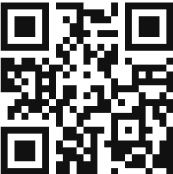

/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


<!DOCTYPE html>
<html lang="zh-Hant-TW"><head>
<meta charset="utf-8"/>
<title>台北市內湖區買房 | 永慶房仲網</title>
<base href="/"/>
<meta content="width=device-width, initial-scale=1, maximum-scale=1" name="viewport"/>
<meta content="telephone=no" name="format-detection"/>
<meta content="notranslate" name="google"/>
<link href="favicon.ico" rel="icon" type="image/x-icon"/>
<link as="font" crossorigin="anonymous" href="https://cdn.yungching.com.tw/fp/yc/common/fonts/poppins.woff2" rel="preload" type="font/woff2"/>
<link as="font" crossorigin="anonymous" href="https://cdn.yungching.com.tw/fp/yc/common/fonts/oswald.woff2" rel="preload" type="font/woff2"/>
<link href="/mansion/styles-VVDIEA23.css" rel="stylesheet"/><style ng-app-id="ng">.main[_ngcontent-ng-c757704105]{background-color:#f2f2f2}.main[_ngcontent-ng-c757704105]:after{content:"";display:block;width:100%;height:1px}</style><style ng-app-id="ng">@keyframes _ngcontent-ng-c4108280727_shine{to{background-position-x:-200%}}@keyframes _ngcontent-
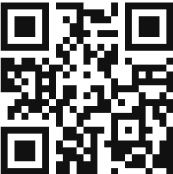

/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
IOPub data rate exceeded.
The Jupyter server will temporari

<!DOCTYPE html>
<html lang="zh-Hant-TW"><head>
<meta charset="utf-8"/>
<title>台北市內湖區買房 | 永慶房仲網</title>
<base href="/"/>
<meta content="width=device-width, initial-scale=1, maximum-scale=1" name="viewport"/>
<meta content="telephone=no" name="format-detection"/>
<meta content="notranslate" name="google"/>
<link href="favicon.ico" rel="icon" type="image/x-icon"/>
<link as="font" crossorigin="anonymous" href="https://cdn.yungching.com.tw/fp/yc/common/fonts/poppins.woff2" rel="preload" type="font/woff2"/>
<link as="font" crossorigin="anonymous" href="https://cdn.yungching.com.tw/fp/yc/common/fonts/oswald.woff2" rel="preload" type="font/woff2"/>
<link href="/mansion/styles-VVDIEA23.css" rel="stylesheet"/><style ng-app-id="ng">.main[_ngcontent-ng-c757704105]{background-color:#f2f2f2}.main[_ngcontent-ng-c757704105]:after{content:"";display:block;width:100%;height:1px}</style><style ng-app-id="ng">@keyframes _ngcontent-ng-c4108280727_shine{to{background-position-x:-200%}}@keyframes _ngcontent-
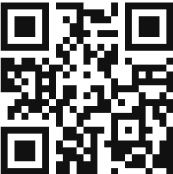

In [9]:
import requests
from bs4 import BeautifulSoup

# these range should be decided by how many pages the link have, it would be range(1, page+1)
for i in range(1,6):
    r = requests.get(f"https://buy.yungching.com.tw/list/住宅_p/台北市-內湖區_c/無電梯公寓_type/n_park/?od=10&pg={i}", verify=False)
    soup = BeautifulSoup(r.text, "html.parser")
    print(soup)
    q = soup.find_all("script", type="application/ld+json")[2]
    with open("houseURL.txt", "a") as fw:
        for content in eval(q.text)["itemListElement"]:
            fw.write(content["url"]+"\n")

# clean duplicate URL
cleanDup = list(set(fr.readlines()))
with open("houseURL.txt", "w") as fw:
    for line in cleanDup:
        fw.write(line)
    

### build dataset with logic provided in documentation

### step1: create method for calculating the distance between metro stations and properties (straight-line distance)

In [5]:
import overpy

def getNearestStationEz(latitude, longitude, dist = 2000):
    api = overpy.Overpass()

    # search all metro station in dist meters (gpt is really bad at this special syntex)
    query = f"""
    node[subway=yes](around:{dist},{latitude},{longitude});
    out body;
    """
    result = api.query(query)

    # fetch metro station's longitude and latitude
    stations = []
    for node in result.nodes:
        if "name" not in node.tags: continue
        stations.append({
            'name': node.tags["name"],
            'lat': node.lat,
            'lon': node.lon
        })

    # find shortest distance between stations
    min_distance = float('inf')
    nearest_station = None

    for station in stations:
        try:
            # calc distance between station and property
            length = haversine_distance(latitude, longitude, float(station['lat']), float(station['lon']))
            if length < min_distance:
                min_distance = length
                nearest_station = station
        except Exception as e:
            continue

    if nearest_station:
        return nearest_station['name'], min_distance
    else:
        print(f"{latitude},{longitude} 未找到可達的捷運站。")
        return "N/A", 10000

### create method for calculating the distance between metro stations and properties (walking distance)

In [7]:
import overpy
import osmnx as ox
import networkx as nx
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # earth radius (km)
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a)) * 1000

# Download network graph from OSMX distance center of Neihu District 5000 meters (optimize)
G = ox.graph_from_point((25.084153, 121.589678), dist=5000, network_type='walk')

def getNearestStationReal(latitude, longitude, dist = 2000):
    api = overpy.Overpass()

    # search all metro station in dist meters (gpt is really bad at this special syntex)
    query = f"""
    node[subway=yes](around:{dist},{latitude},{longitude});
    out body;
    """
    result = api.query(query)

    # fetch metro station's longitude and latitude
    stations = []
    for node in result.nodes:
        if "name" not in node.tags: continue
        stations.append({
            'name': node.tags["name"],
            'lat': node.lat,
            'lon': node.lon
        })


    # find the nearest nodes of properties
    orig_node = ox.distance.nearest_nodes(G, longitude, latitude)

    min_distance = float('inf')
    nearest_station = None

    for station in stations:
        try:
            # find the nearest nodes of metro station
            dest_node = ox.distance.nearest_nodes(G, float(station['lon']), float(station['lat']))
            # calc shortest path of weighted graph use networkx module
            length = nx.shortest_path_length(G, orig_node, dest_node, weight='length')
            if length < min_distance:
                min_distance = length
                nearest_station = station
        except Exception as e:
            continue

    if nearest_station:
        return nearest_station['name'], min_distance
    else:
        print(f"{latitude},{longitude} 未找到可達的捷運站。")
        return "N/A", 10000

### step 2: craw data and calc distance

In [12]:
import requests
from bs4 import BeautifulSoup
import json
import time

with open("resultOverpassPhysic.csv", "w", encoding="utf-8") as fw:
    fw.write("id,price,area,age,rooms,distanceToMetro,stationName,distanceSource,longitude,latitude,walkingDistance\n")

# gpt is bad at analyize this website
with open("houseURL.txt", "r") as fr:
    for rawUrl in fr.readlines():
        url = rawUrl.strip()
        houseID = url.split('/')[-1]
        with open("resultOverpassPhysic.csv", "a", encoding="utf-8") as fwCSV:
            r = requests.get(url, verify = False)
            soup = BeautifulSoup(r.text, "html.parser")
            q = soup.find("script", id="ng-state")
            dct = json.loads(q.text)
            data = list(dct.values())[0]['b']['data']
            fwCSV.write(f"{data['showCaseNo']},")
            fwCSV.write(f"{data['price']},")
            fwCSV.write(f"{data['pinInfo']['regArea']},")
            fwCSV.write(f"{data['buildAge']},")
            fwCSV.write(f"{data['patternInfo']['room']},")
            print(data['patternInfo']['room'])
            latitude, longitude = data['geoInfo']['latitude'], data['geoInfo']['longitude']
            print(latitude, longitude)
            time.sleep(0.5)
            r = requests.get(f"https://buy.yungching.com.tw/api/v2/information/poi?id={houseID}", verify = False) # this api is hidden in the page loading process (lazy load?)
            dct = json.loads(r.text)['data']['pois']
            isAnyStation = False
            for data in dct: # if distance data can be found in 永慶's website
                if data['poiItem'] == '交通':
                    for content in data['poiDetails']:
                        if content['poiSubName'] == '捷運' and "施工中" not in content['poiTitle'] and "規劃中" not in content['poiTitle']:
                            print(content['poiTitle'])
                            print(content['distance'])
                            fwCSV.write(f"{content['distance']},")
                            fwCSV.write(f"{content['poiTitle']},")
                            fwCSV.write(f"永慶房屋,")
                            isAnyStation = True
                            break
                    break
            if not isAnyStation: # else calc disatance by function created above
                stationName, distance = getNearestStationEz(latitude, longitude)
                time.sleep(1)
                fwCSV.write(f"{distance},{stationName}站,")
                fwCSV.write(f"overPass,")
                print(f"{stationName}站\n{distance}")
            fwCSV.write(f"{latitude},{longitude}")

            stationName, distance = getNearestStationReal(latitude, longitude)
            fwCSV.write(f",{distance}\n")


/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


2
25.0272165470856 121.50876051734


/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


植物園站
400.99758515385696


/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


5
25.0696566904 121.614312984


/usr/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'buy.yungching.com.tw'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


捷運東湖站
380.52181217249057


KeyboardInterrupt: 

### observe data with scatter plot

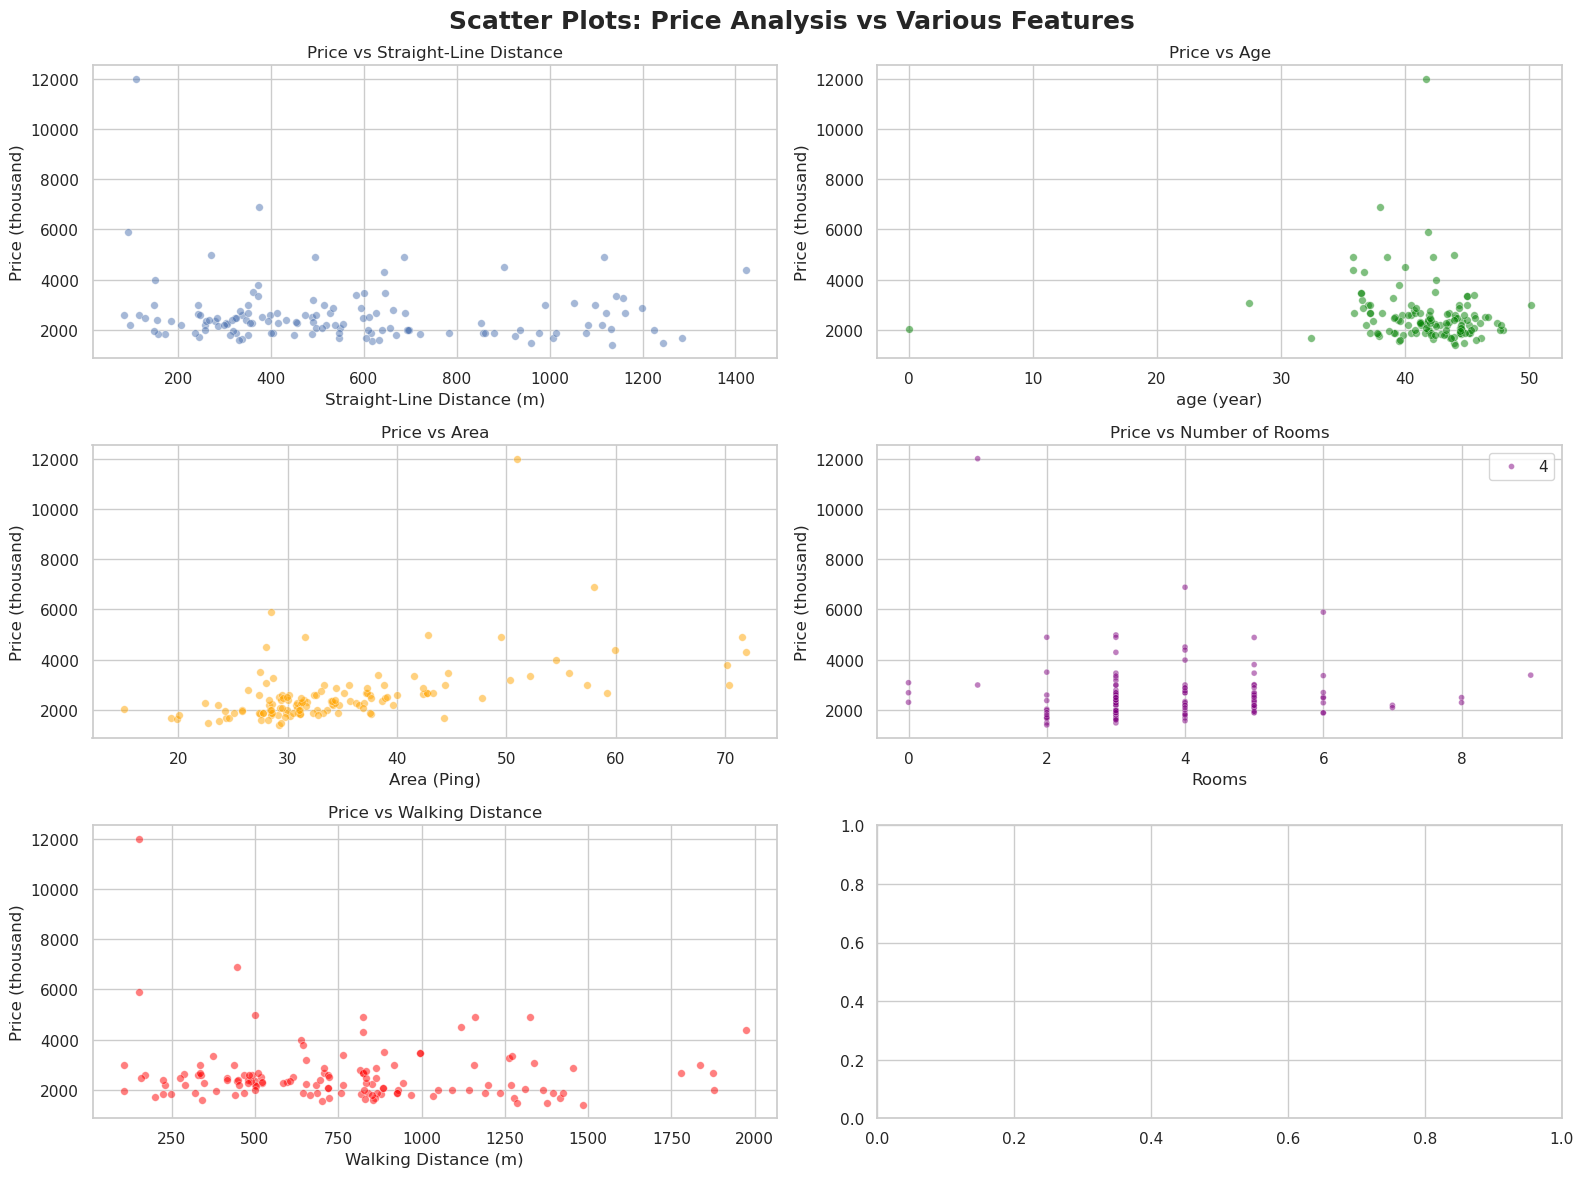

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("resultOverpassPhysic.csv")

# create subgraph
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Scatter Plots: Price Analysis vs Various Features", fontsize=18, fontweight='bold')

# Plot 1: Price vs Distance to Metro
sns.scatterplot(ax=axes[0, 0], data=df, x="distanceToMetro", y="price", alpha=0.5, s=30)
axes[0, 0].set_title("Price vs Straight-Line Distance")
axes[0, 0].set_xlabel("Straight-Line Distance (m)")
axes[0, 0].set_ylabel("Price (thousand)")
axes[0, 0].grid(True)

# Plot 2: Price vs Age
sns.scatterplot(ax=axes[0, 1], data=df, x="age", y="price", alpha=0.5, s=30, color="green")
axes[0, 1].set_title("Price vs Age")
axes[0, 1].set_xlabel("age (year)")
axes[0, 1].set_ylabel("Price (thousand)")
axes[0, 1].grid(True)

# Plot 3: Price vs Area
sns.scatterplot(ax=axes[1, 0], data=df, x="area", y="price", alpha=0.5, s=30, color="orange")
axes[1, 0].set_title("Price vs Area")
axes[1, 0].set_xlabel("Area (Ping)")
axes[1, 0].set_ylabel("Price (thousand)")
axes[1, 0].grid(True)

# Plot 4: Price vs Rooms (strip plot with jitter)
sns.scatterplot(ax=axes[1, 1], data=df, x="rooms", y="price", alpha=0.5, size=4, color="purple")
axes[1, 1].set_title("Price vs Number of Rooms")
axes[1, 1].set_xlabel("Rooms")
axes[1, 1].set_ylabel("Price (thousand)")
axes[1, 1].grid(True)

# Plot 5: Price vs Walking Distance
sns.scatterplot(ax=axes[2, 0], data=df, x="walkingDistance", y="price", alpha=0.5, s=30, color="red")
axes[2, 0].set_title("Price vs Walking Distance")
axes[2, 0].set_xlabel("Walking Distance (m)")
axes[2, 0].set_ylabel("Price (thousand)")
axes[2, 0].grid(True)

# adjust layout
plt.tight_layout()
plt.show()


### compare the difference between with outlier and without outlier

108


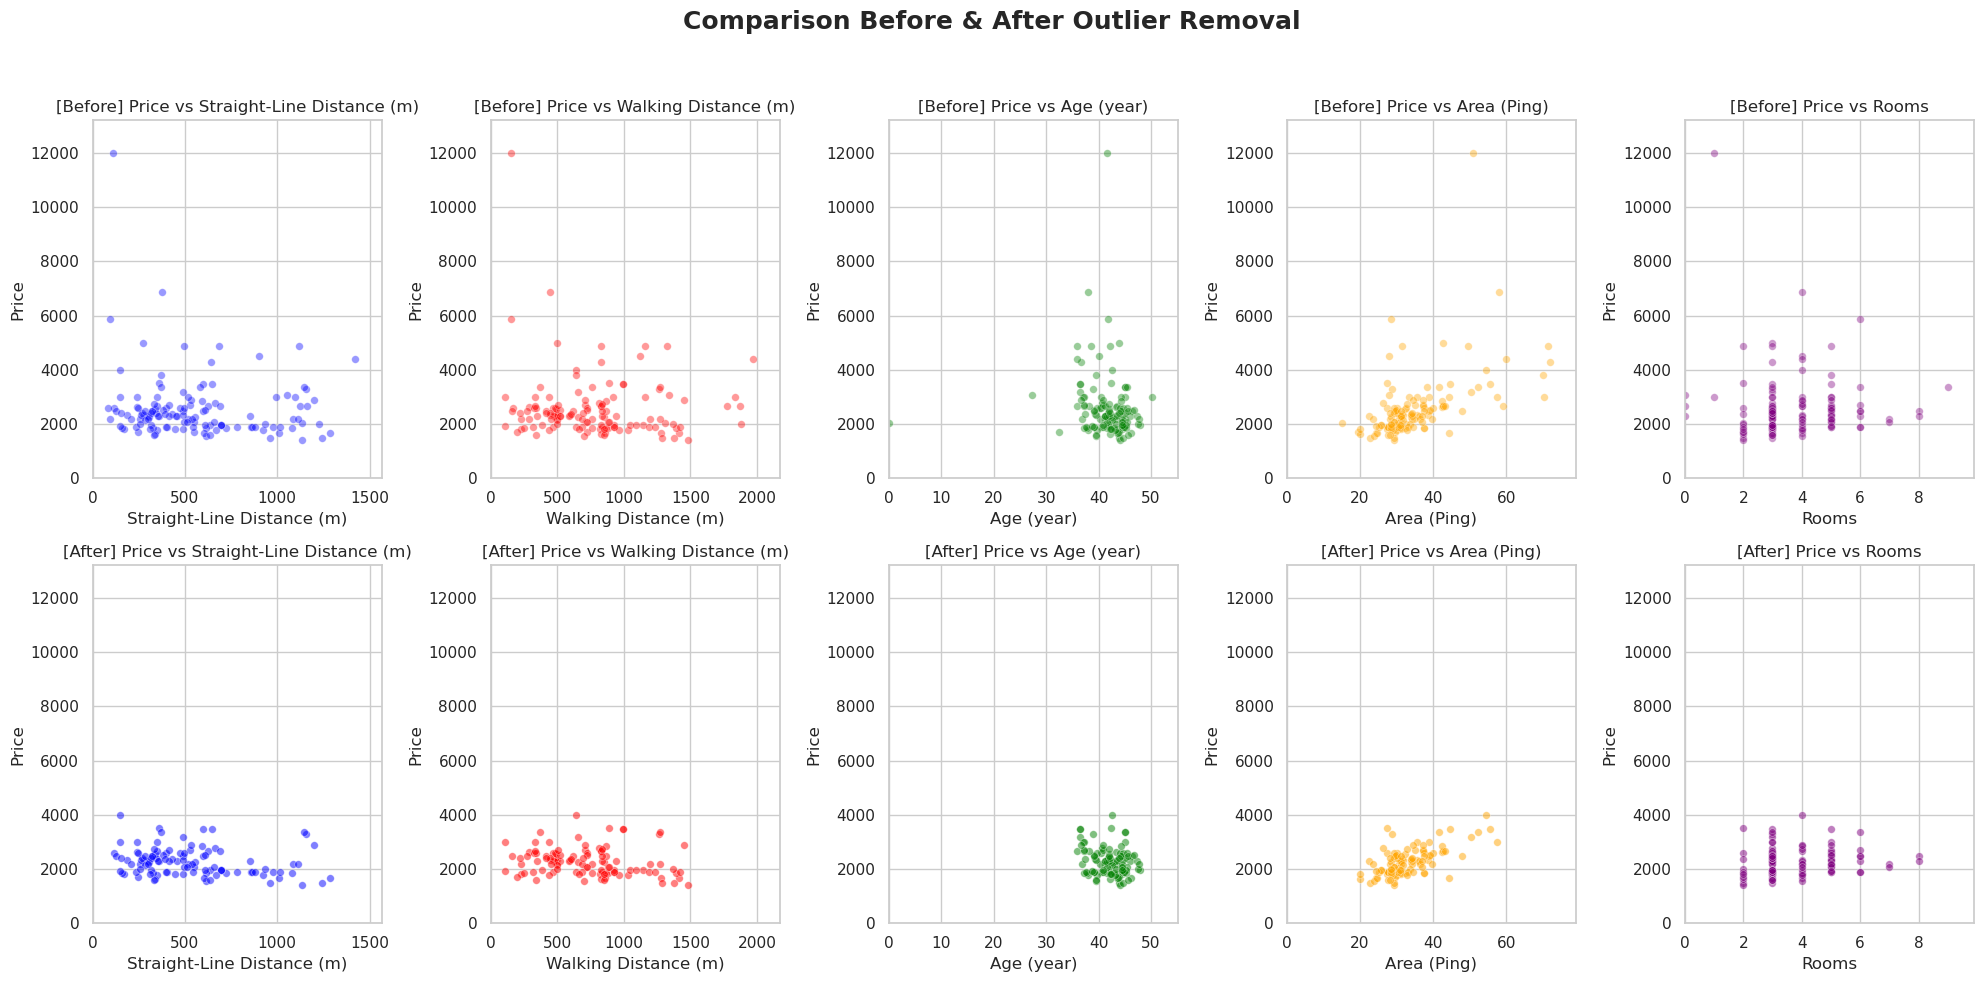

In [200]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df_raw = pd.read_csv("resultOverpassPhysic.csv")

# remove outlier
df_clean = df_raw[
    (df_raw["price"].between(1000, 4000)) &
    (df_raw["distanceToMetro"].between(100, 1400)) &
    (df_raw["walkingDistance"].between(100, 1500)) &
    (df_raw["age"].between(35, 50)) &
    (df_raw["area"].between(10, 70)) &
    (df_raw["rooms"].between(1, 8))
]
print(len(df_clean))

plot_pairs = [
    ("distanceToMetro", "Straight-Line Distance (m)", "blue"),
    ("walkingDistance", "Walking Distance (m)", "red"),
    ("age", "Age (year)", "green"),
    ("area", "Area (Ping)", "orange"),
    ("rooms", "Rooms", "purple")
]

# compare（Before vs After）
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle("Comparison Before & After Outlier Removal", fontsize=18, fontweight="bold")

ylim = (0, df_raw["price"].max()*1.10)
for i, (x, xlabel, color) in enumerate(plot_pairs):

    # make x, y have same range
    xlim = (0, df_raw[x].max()*1.10)
    
    # Before cleaning
    sns.scatterplot(data=df_raw, x=x, y="price", ax=axes[0, i], alpha=0.4, s=30, color=color)
    axes[0, i].set_title(f"[Before] Price vs {xlabel}")
    axes[0, i].set_xlabel(xlabel)
    axes[0, i].set_ylabel("Price")
    axes[0, i].set(xlim=xlim)
    axes[0, i].set(ylim=ylim)

    # After cleaning
    sns.scatterplot(data=df_clean, x=x, y="price", ax=axes[1, i], alpha=0.5, s=30, color=color)
    axes[1, i].set_title(f"[After] Price vs {xlabel}")
    axes[1, i].set_xlabel(xlabel)
    axes[1, i].set_ylabel("Price")
    axes[1, i].set(xlim=xlim)
    axes[1, i].set(ylim=ylim)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### do the OLS regression

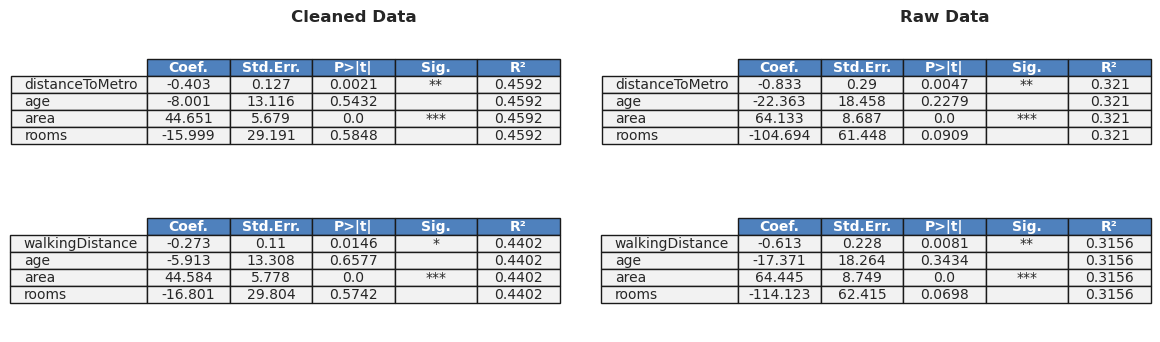

In [198]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv("resultOverpassPhysic.csv")

# OLS regression
def run_ols_summary(df, distanceMethod):
    X = sm.add_constant(df[[distanceMethod, "age", "area", "rooms"]])
    y = df["price"]
    model = sm.OLS(y, X).fit()
    summary = model.summary2().tables[1].drop(index="const")
    def mark_sig(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        return ''
    summary["Coef."] = summary["Coef."].round(3).astype(str)
    summary["Std.Err."] = summary["Std.Err."].round(3)
    summary["P>|t|"] = summary["P>|t|"].round(4)
    summary['Sig.'] = summary["P>|t|"].apply(mark_sig)
    summary["R²"] = round(model.rsquared, 4)
    return summary[["Coef.", "Std.Err.", "P>|t|", "Sig.","R²"]]

# build table
table1 = run_ols_summary(df_clean, "distanceToMetro")
table2 = run_ols_summary(df_raw, "distanceToMetro")
table3 = run_ols_summary(df_clean, "walkingDistance")
table4 = run_ols_summary(df_raw, "walkingDistance")

# left right compare
fig, axes = plt.subplots(2, 2, figsize=(12, 4))
        
# table1
axes[0, 0].axis("off")
tbl1 = pd.plotting.table(
    ax=axes[0, 0], data=table1, colWidths=[0.25]*len(table1.columns),
    cellLoc='center', loc='center'
)
axes[0, 0].set_title("Cleaned Data", fontweight='bold')

# table2
axes[0, 1].axis("off")
tbl2 = pd.plotting.table(
    ax=axes[0, 1], data=table2, colWidths=[0.25]*len(table2.columns),
    cellLoc='center', loc='center'
)
axes[0, 1].set_title("Raw Data", fontweight='bold')

# table3
axes[1, 0].axis("off")
tbl3 = pd.plotting.table(
    ax=axes[1, 0], data=table3, colWidths=[0.25]*len(table1.columns),
    cellLoc='center', loc='center'
)

# table4
axes[1, 1].axis("off")
tbl4 = pd.plotting.table(
    ax=axes[1, 1], data=table4, colWidths=[0.25]*len(table2.columns),
    cellLoc='center', loc='center'
)

# adjust appearence
for tbl in [tbl1, tbl2, tbl3, tbl4]:
    for key, cell in tbl.get_celld().items():
        cell.set_fontsize(10)
        if key[0] == 0:  # header
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor("#4F81BD")
        else:
            cell.set_facecolor("#F2F2F2")

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.show()


### plot relationship between prices vs area, price vs straight-line distance to metro, price to walking distance to metro

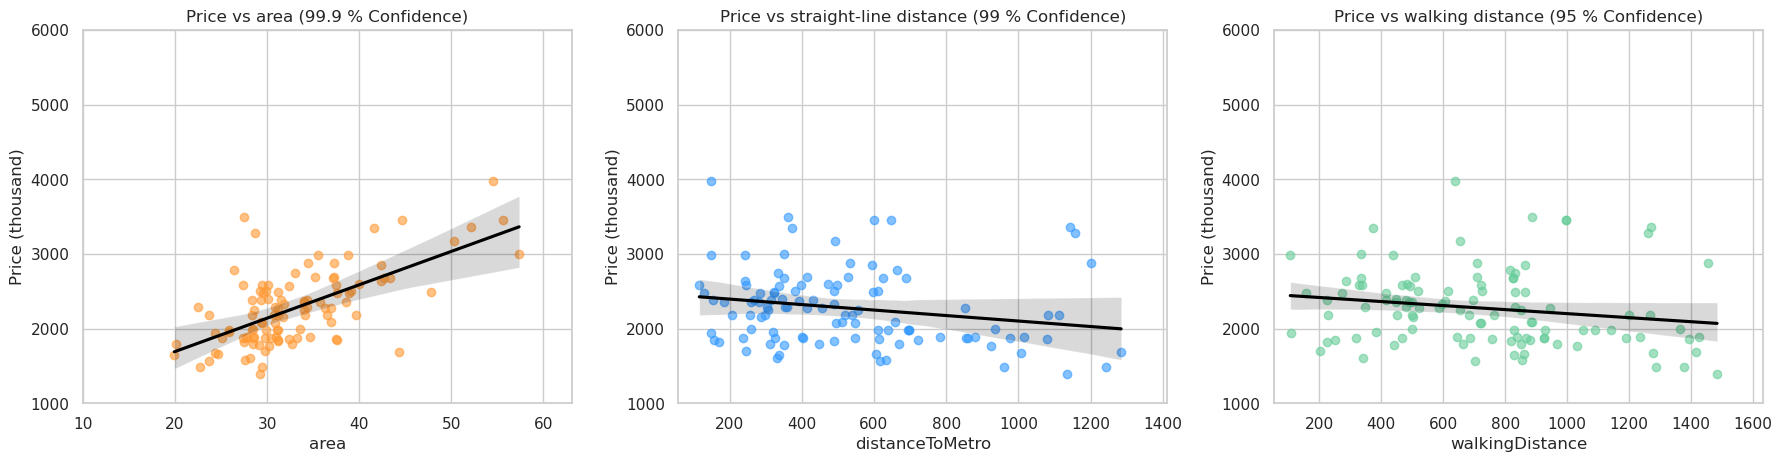

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("resultOverpassPhysic.csv")

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# set feature, color and cofidence
features = ["area", "distanceToMetro", "walkingDistance"]
names = ["area", "straight-line distance", "walking distance"]
colors = ["#FF9933", "#3399FF", "#66CC99"]
cis = [99.9, 99, 95]

ylim = (1000, 6000)
for ax, feature, name, color, ci in zip(axes, features, names, colors, cis):

    xlim = (df_clean[feature].min()*0.5, df_clean[feature].max()*1.10)
    
    sns.regplot(
        data=df_clean,
        x=feature,
        y="price",
        ax=ax,
        color=color,
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "black"},
        ci=ci
    )
    ax.set_title(f"Price vs {name} ({ci} % Confidence)")
    ax.set_xlabel(feature)
    ax.set_ylabel("Price (thousand)")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


### plot relationship between prices and distance between properties and operating metro station (Fig3)

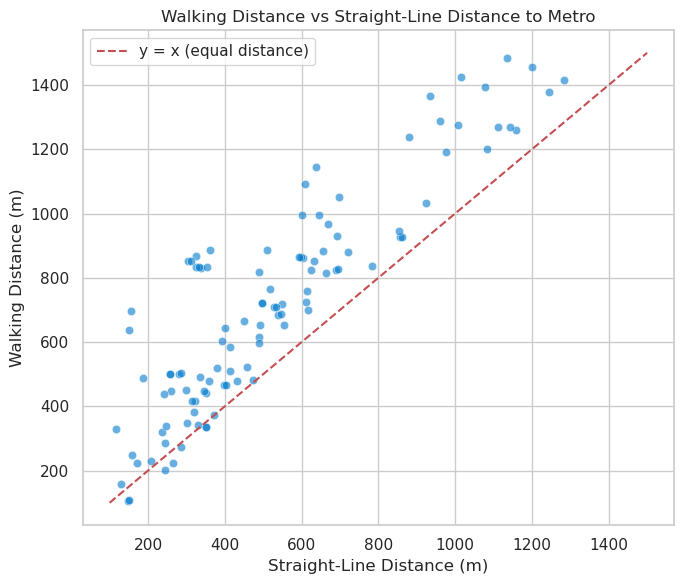

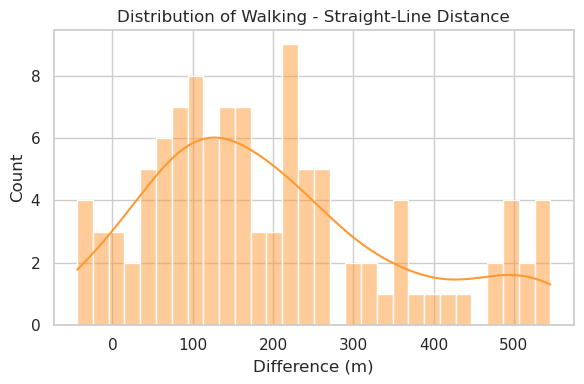

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 載入資料
df = pd.read_csv("resultOverpassPhysic.csv")

# 建立圖
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_clean, x="distanceToMetro", y="walkingDistance", alpha=0.6, color="#007acc")

# 畫出 y = x 線（理論上完全相等的情況）
lims = [100, 1500]
plt.plot(lims, lims, 'r--', linewidth=1.5, label="y = x (equal distance)")

# 標題與標籤
plt.title("Walking Distance vs Straight-Line Distance to Metro")
plt.xlabel("Straight-Line Distance (m)")
plt.ylabel("Walking Distance (m)")
plt.legend()
plt.tight_layout()
plt.show()

df_clean["delta"] = df_clean["walkingDistance"] - df_clean["distanceToMetro"]

plt.figure(figsize=(6, 4))
sns.histplot(df_clean["delta"], bins=30, kde=True, color="#FF9933")
plt.title("Distribution of Walking - Straight-Line Distance")
plt.xlabel("Difference (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

